## Import Paths

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
PROJECT_PATH = Path.cwd().parent
CLEANED_PATH = PROJECT_PATH / "04_Cleaned_Data"

TRANSFORMED_FILE = (
    CLEANED_PATH / "Airline_Flights_January_2024_Cleaned.csv"
)

df = pd.read_csv(
    TRANSFORMED_FILE,
    low_memory=False
)

df["FlightDate"] = pd.to_datetime(
    df["FlightDate"],
    errors="coerce"
)

print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))

Rows: 547,271
Columns: 93


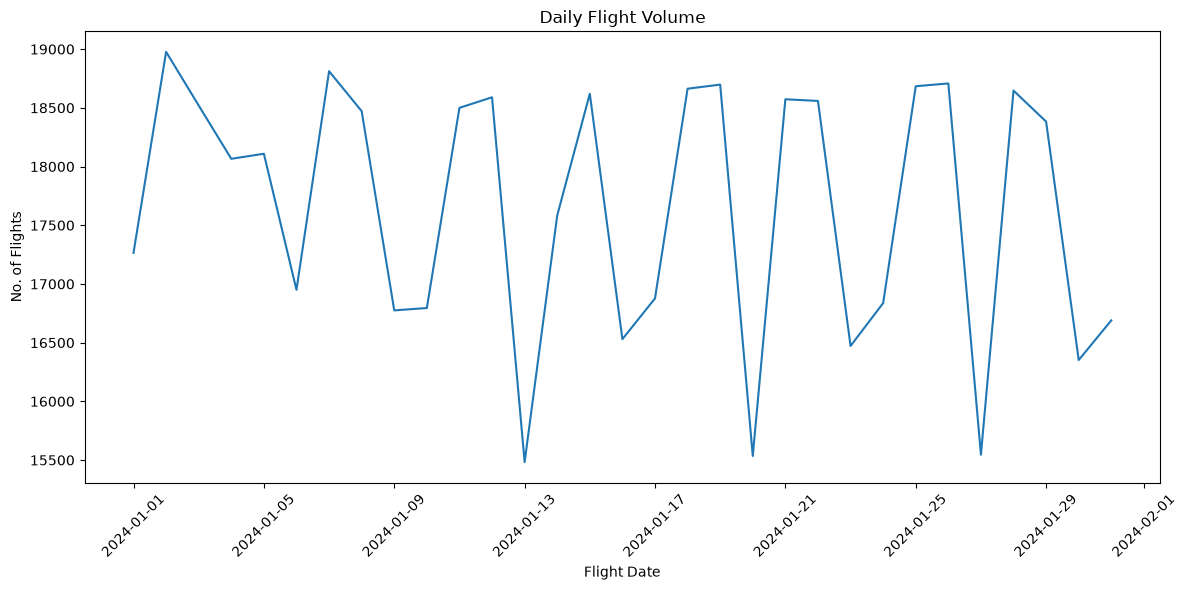

In [4]:
daily_flights = (
    df.groupby("FlightDate")
    .size()
    .reset_index(name="Flight_Counts")

)

plt.figure(figsize=(12, 6))

plt.plot(daily_flights["FlightDate"], daily_flights["Flight_Counts"])

plt.title("Daily Flight Volume")

plt.xlabel("Flight Date")

plt.ylabel("No. of Flights")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

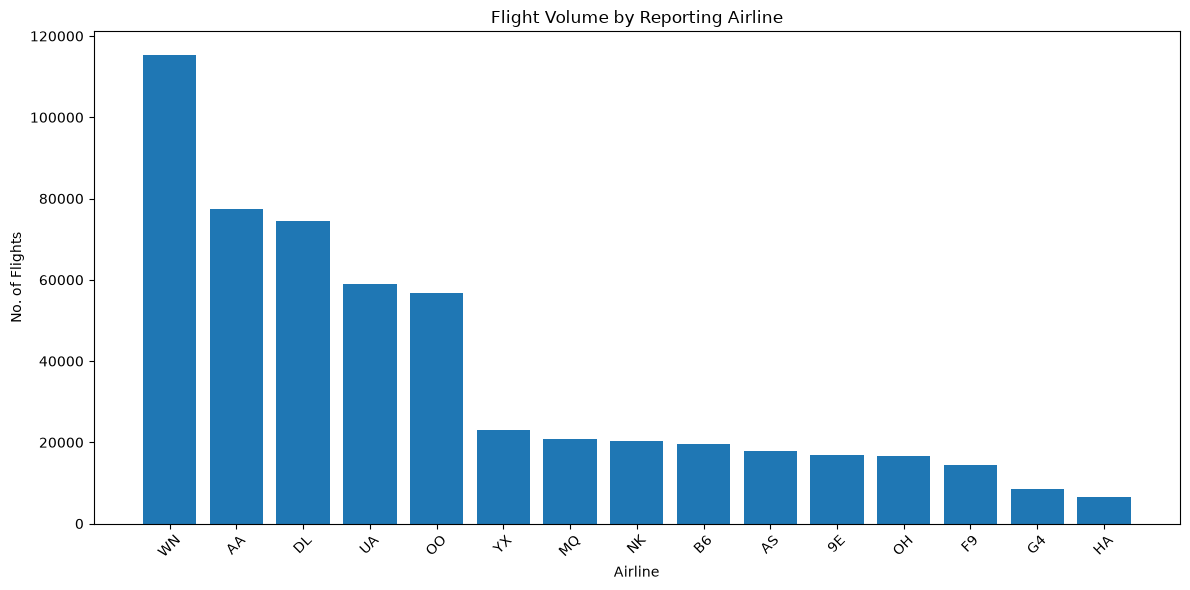

In [5]:
plt.figure(figsize=(12,6))

total_airline = (
    df["Reporting_Airline"]
    .value_counts()
)

plt.bar(total_airline.index, total_airline.values)

plt.title("Flight Volume by Reporting Airline")

plt.xlabel("Airline")

plt.ylabel("No. of Flights")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

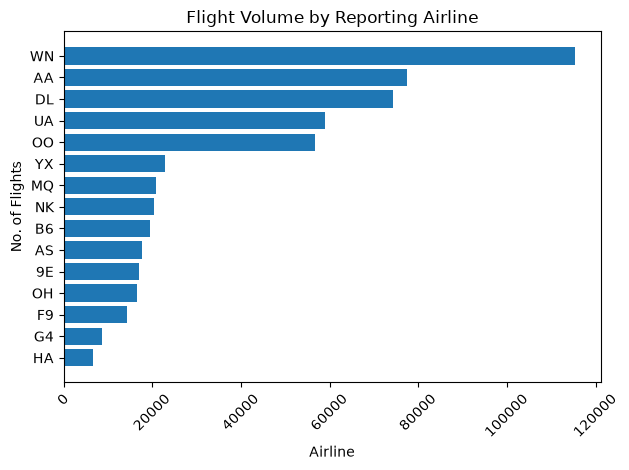

In [6]:
total_airline = (
    total_airline.sort_values()
)

#barh is used for horizontal bar chart
plt.barh(total_airline.index, total_airline.values)

plt.title("Flight Volume by Reporting Airline")

plt.xlabel("Airline")

plt.ylabel("No. of Flights")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

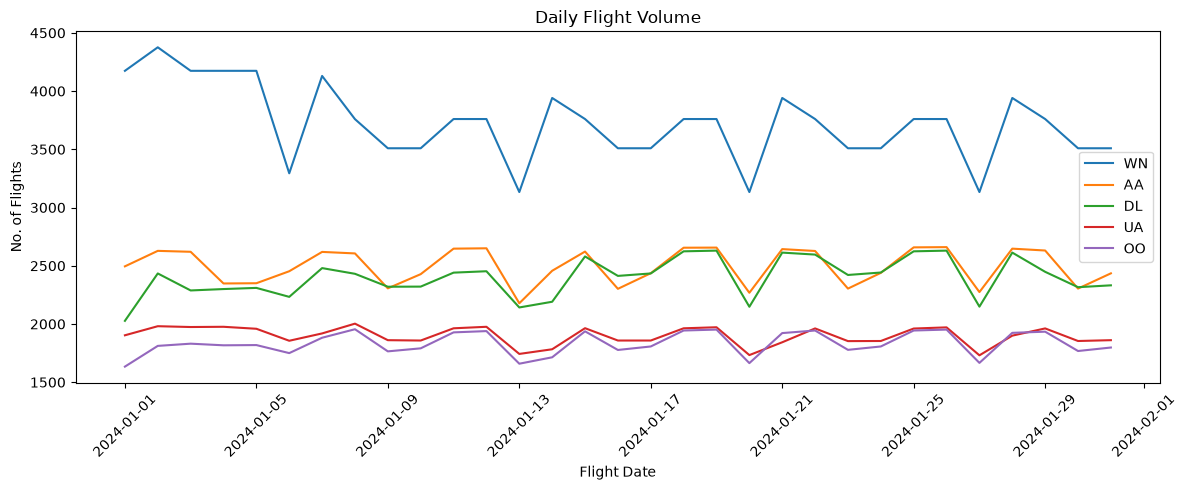

In [7]:
daily_airline = (
    df.groupby(["FlightDate", "Reporting_Airline"])
    .size()
    .reset_index(name="Flight_Counts")
)

top_airlines = (
    df["Reporting_Airline"]
    .value_counts()
    .head(5)
    .index
)
plt.figure(figsize=(12,5))

for airline in top_airlines:

    temp = daily_airline[ daily_airline["Reporting_Airline"] == airline]

    plt.plot(temp["FlightDate"], temp["Flight_Counts"], label= airline)

plt.title("Daily Flight Volume")

plt.xlabel("Flight Date")

plt.ylabel("No. of Flights")

plt.xticks(rotation=45)

plt.tight_layout()

plt.legend()

plt.show()

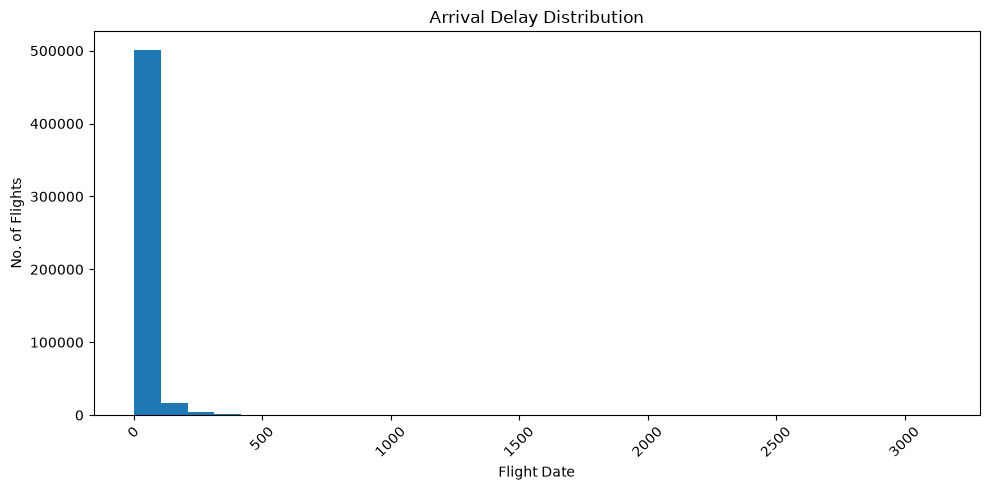

In [8]:
plt.figure(figsize=(10, 5))

arrival_delay = (
    df["ArrDelayMinutes"]
    .dropna()
)

plt.hist(arrival_delay, bins=30)

plt.title("Arrival Delay Distribution")

plt.xlabel("Flight Date")

plt.ylabel("No. of Flights")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_9580\4136404036.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(arrival_delay, vert=False)


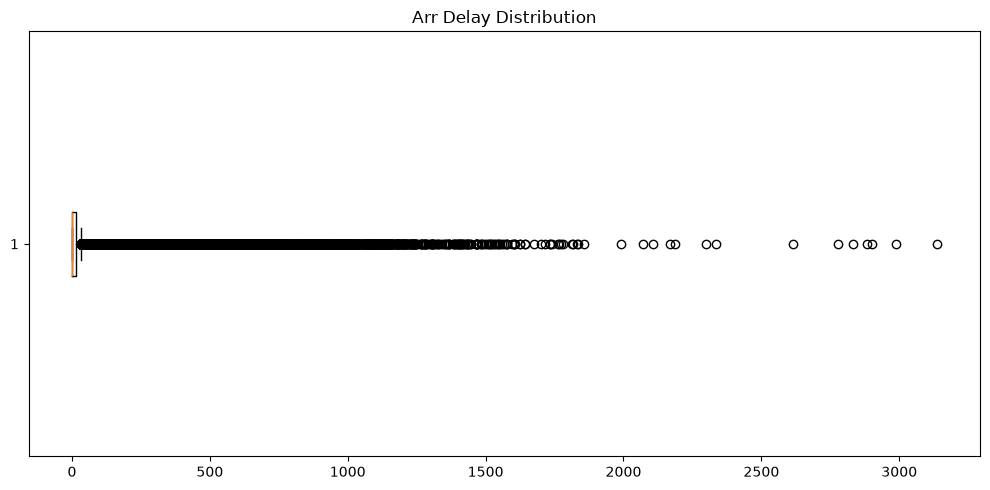

In [9]:
plt.figure(figsize=(10, 5))

plt.boxplot(arrival_delay, vert=False)

plt.title("Arr Delay Distribution")

plt.tight_layout()

plt.show()

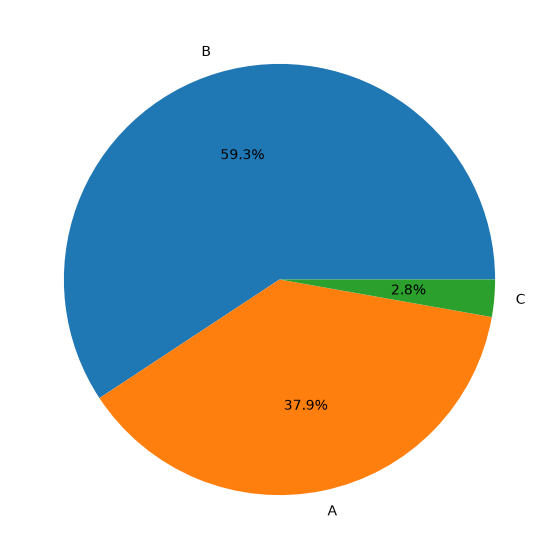

In [10]:
cancellation_status = (
    df["CancellationCode"]
    .value_counts()
)

plt.figure(figsize=(7, 7))

plt.pie(cancellation_status.values, labels=cancellation_status.index, autopct='%1.1f%%')

plt.show()

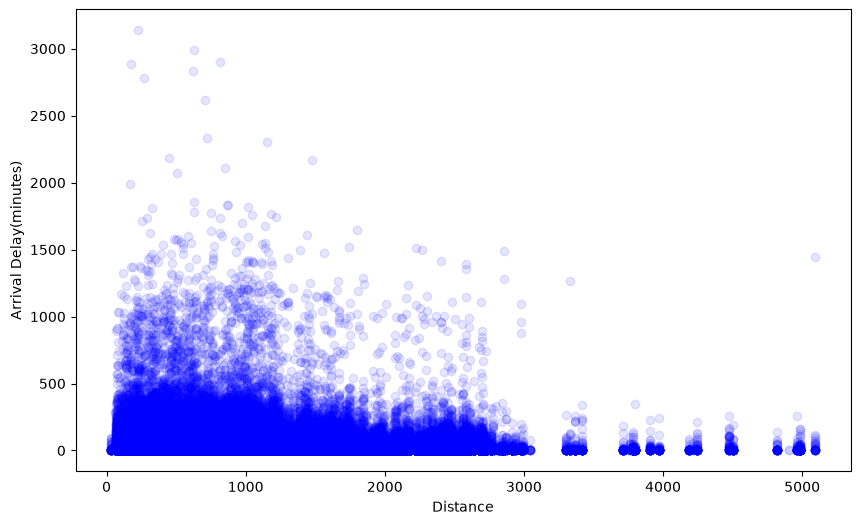

In [11]:
scatter_data = (
    df[["Distance", "ArrDelayMinutes"]].dropna()
)

plt.figure(figsize=(10,6))
plt.scatter(scatter_data["Distance"], scatter_data["ArrDelayMinutes"], alpha=0.1, color='blue')
plt.xlabel("Distance")
plt.ylabel("Arrival Delay(minutes)")

plt.show()

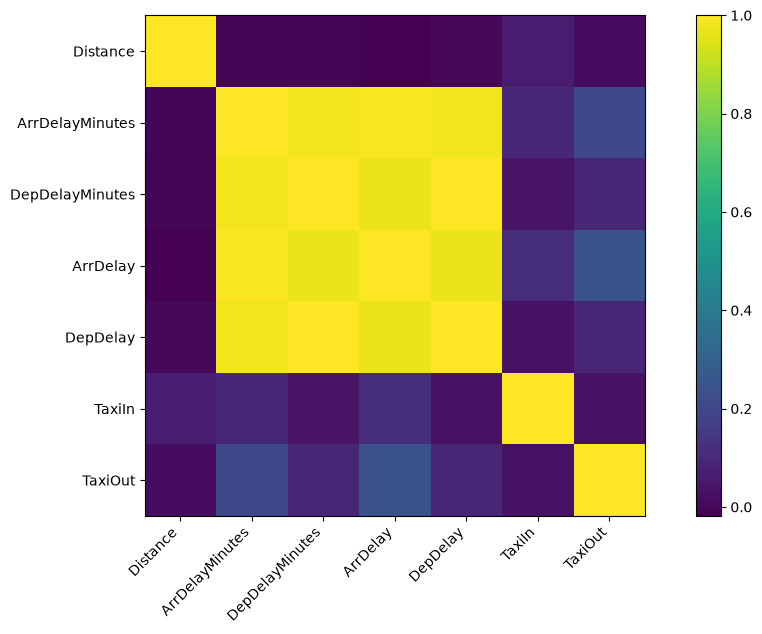

In [40]:
corr_columns = [
"Distance",
"ArrDelayMinutes",
"DepDelayMinutes",
"ArrDelay",
"DepDelay",
"TaxiIn",
"TaxiOut"
]

corr = df[corr_columns].corr()

plt.figure(figsize=(13, 6.5))

plt.imshow(corr, interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(corr_columns)),
    corr_columns,
    rotation = 45,
    ha="right"
)

plt.yticks(
    range(len(corr_columns)),
    corr_columns
)

plt.show()


C:\Users\asus\AppData\Local\Temp\ipykernel_9580\2719977119.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(arrival_delay, vert=False)


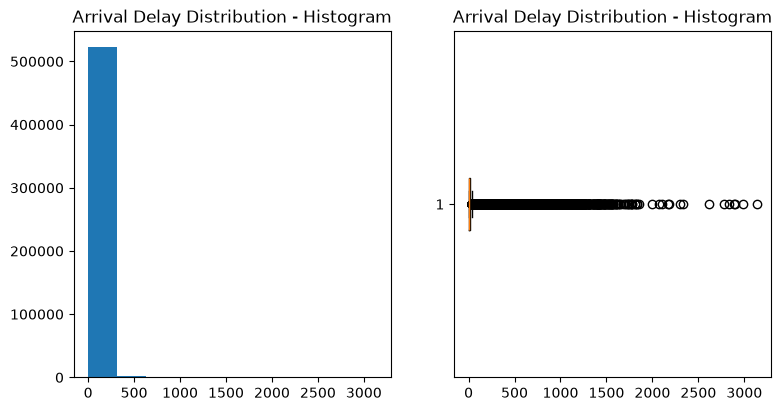

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))

ax[0].hist(arrival_delay, bins=10)
ax[0].set_title("Arrival Delay Distribution - Histogram")

ax[1].boxplot(arrival_delay, vert=False)
ax[1].set_title("Arrival Delay Distribution - Histogram")

plt.show()

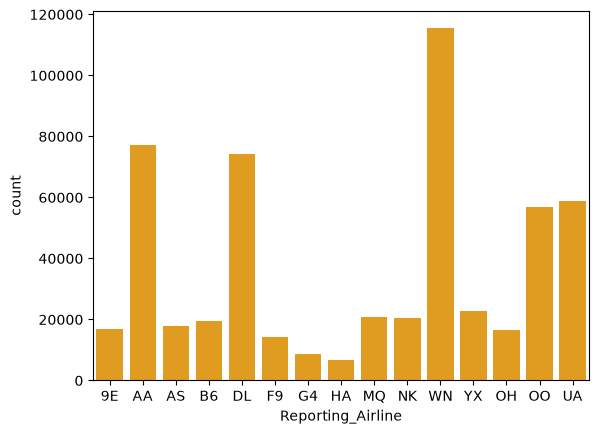

In [14]:
sns.countplot(data=df, x='Reporting_Airline', color='orange')
plt.show()

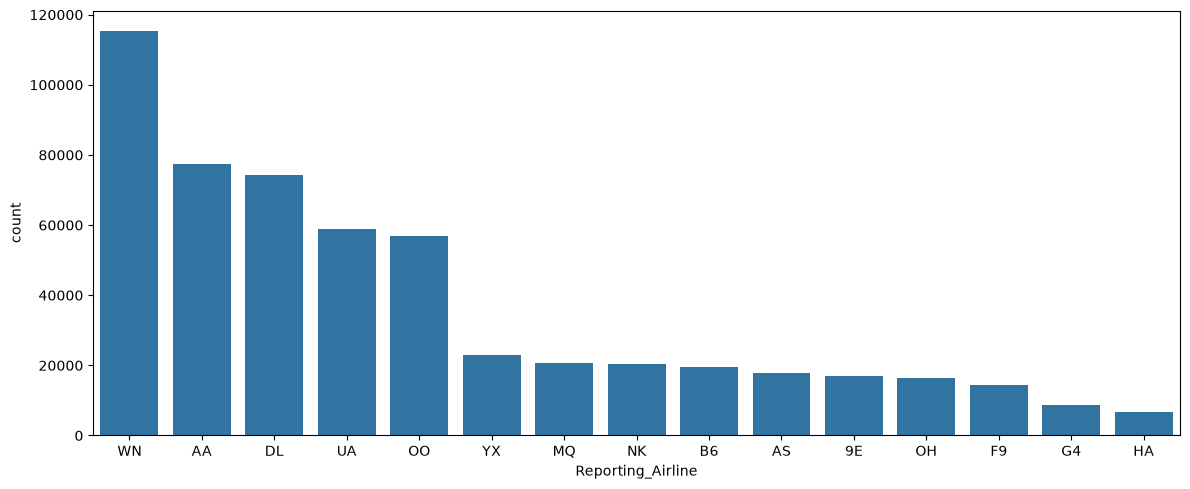

In [42]:
plt.figure(figsize=(12, 5))

sns.countplot(data=df, x="Reporting_Airline",
               order=df["Reporting_Airline"].value_counts(ascending=False).index)
plt.tight_layout()
plt.show()

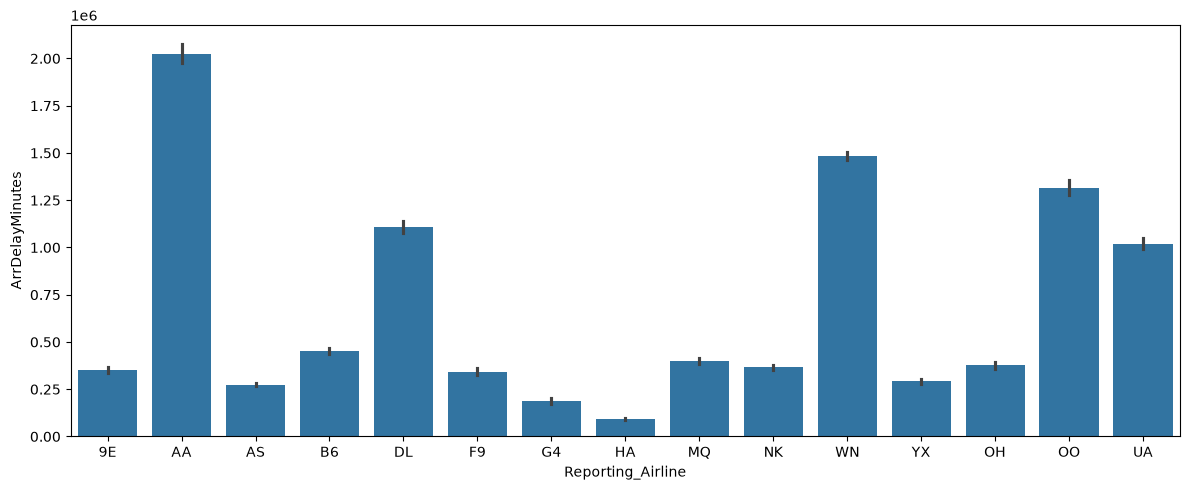

In [43]:
plt.figure(figsize=(12, 5))

sns.barplot(data=df, x="Reporting_Airline", y="ArrDelayMinutes", estimator="sum")
plt.tight_layout()
plt.show()

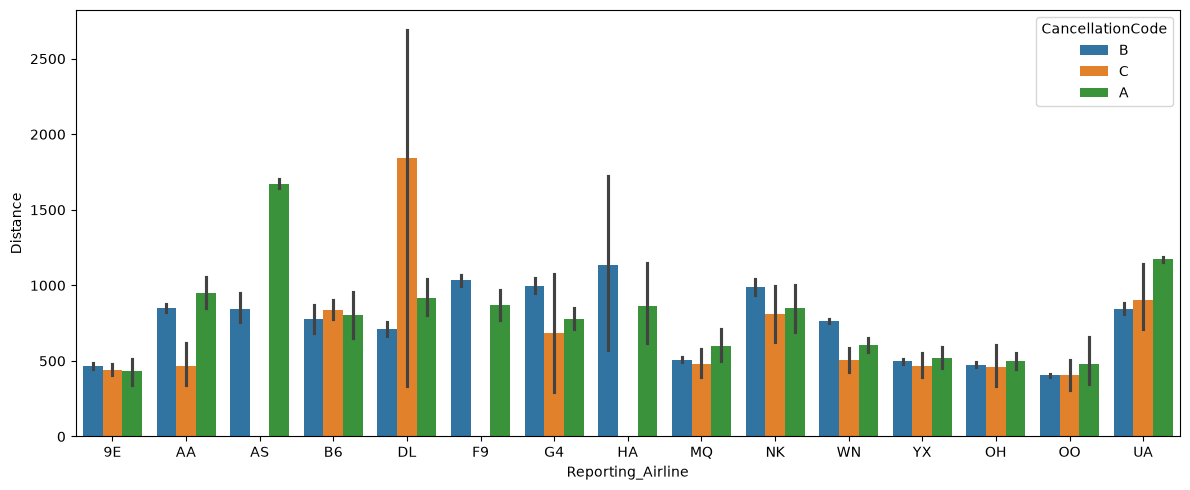

In [44]:
plt.figure(figsize=(12, 5))

sns.barplot(data=df, x="Reporting_Airline", y="Distance", hue="CancellationCode") #hue for category
plt.tight_layout()
plt.show()

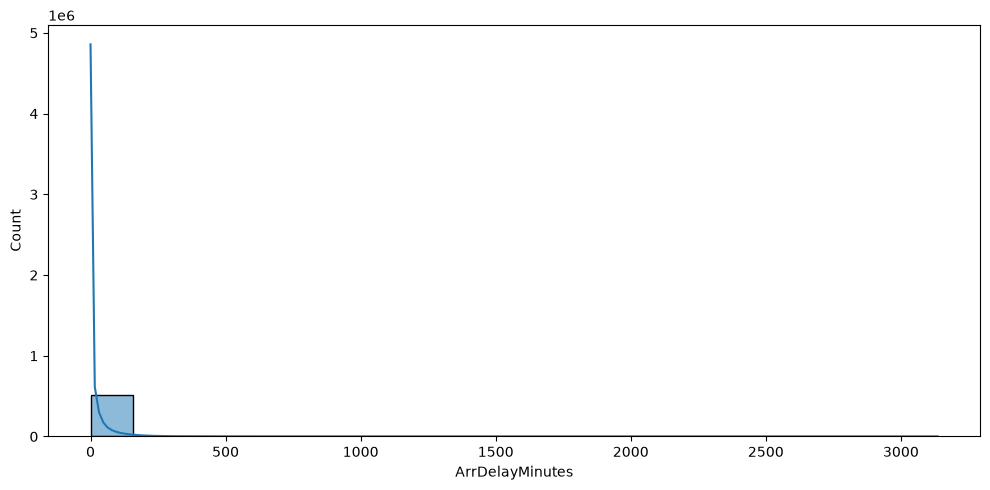

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="ArrDelayMinutes", bins=20, kde=True)
plt.tight_layout()
plt.show()

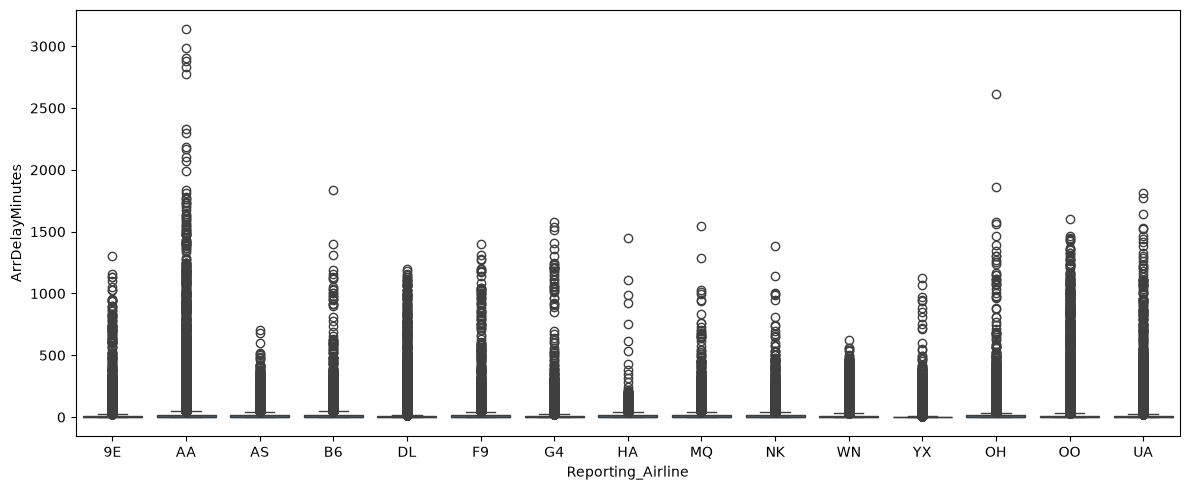

In [46]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=df, x="Reporting_Airline", y="ArrDelayMinutes")
plt.tight_layout()
plt.show()

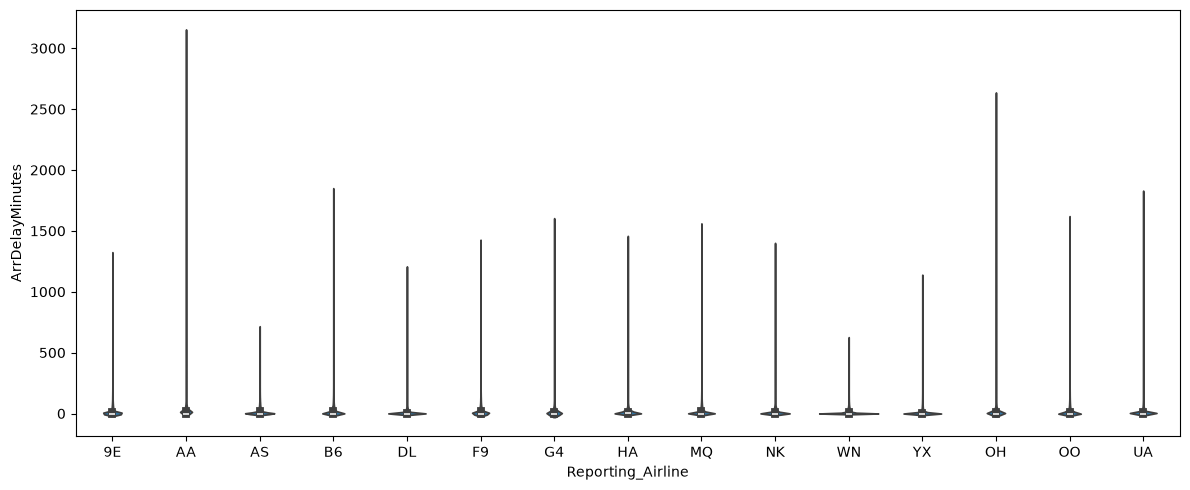

In [47]:
plt.figure(figsize=(12, 5))

sns.violinplot(data=df, x="Reporting_Airline", y="ArrDelayMinutes")
plt.tight_layout()
plt.show()

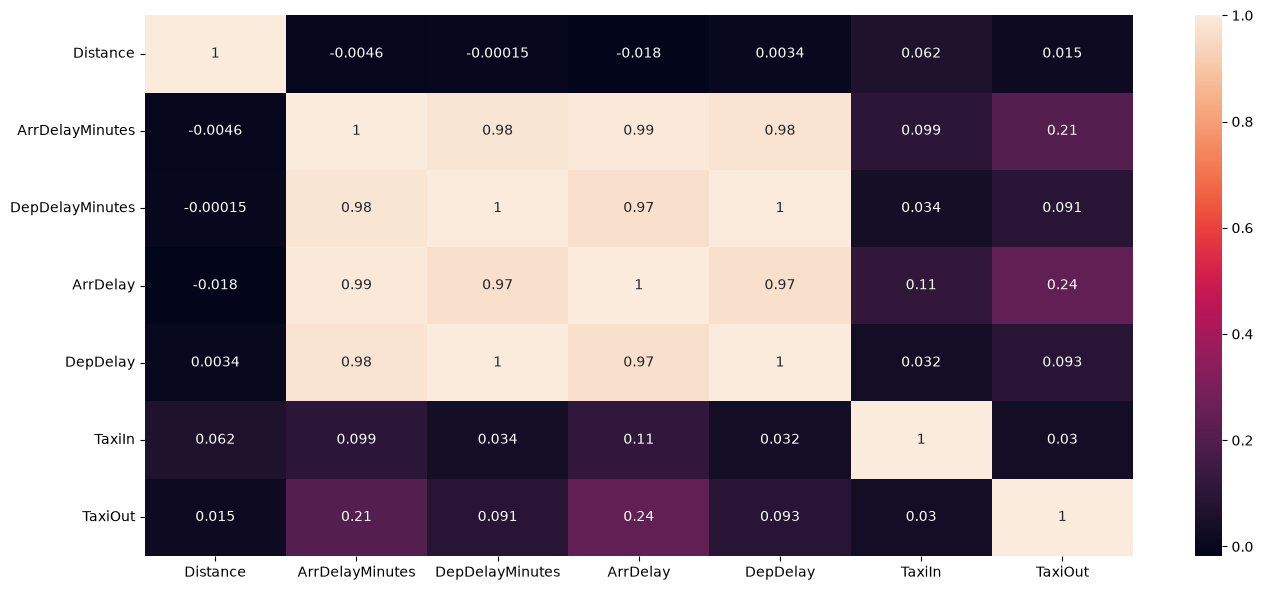

In [48]:
plt.figure(figsize=(14, 6))

sns.heatmap(corr, annot=True)
plt.tight_layout()
plt.show()

In [32]:
relation = (df[["Distance", "ArrDelayMinutes"]]
.dropna()
.sample(min(5000, len(df))))

relation

,Distance,ArrDelayMinutes
391,269.0,0.0
276419,1107.0,32.0
319474,602.0,23.0
313521,1199.0,14.0
148590,134.0,0.0
...,...,...
205544,240.0,0.0
206787,763.0,0.0
336404,701.0,0.0
1429,151.0,0.0


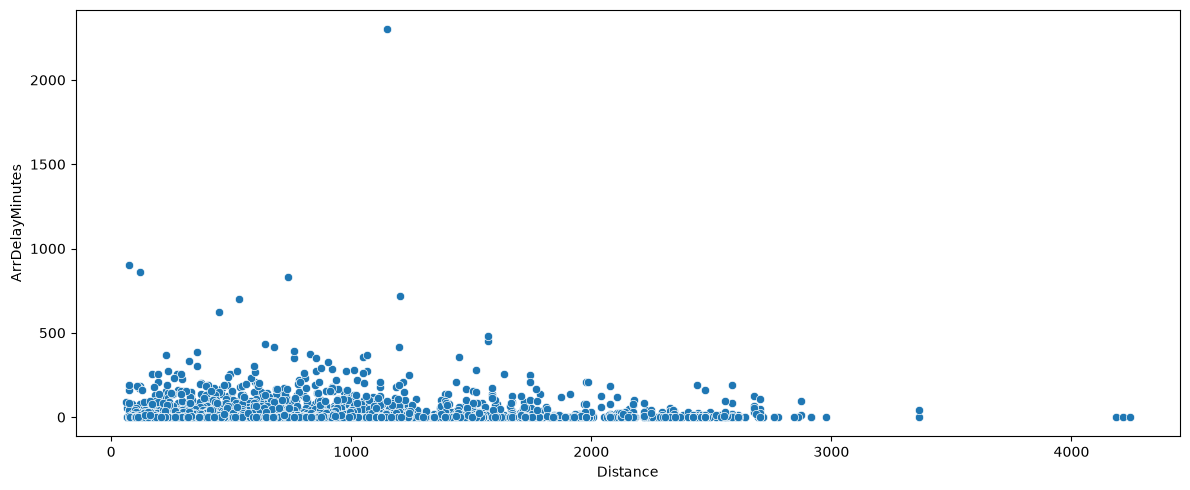

In [49]:
plt.figure(figsize=(12, 5))

sns.scatterplot(x= relation["Distance"], y= relation["ArrDelayMinutes"])
plt.tight_layout()
plt.show()

In [37]:
relation = (df[["Distance", "ArrDelayMinutes", "Reporting_Airline"]]
.dropna()
.sample(min(5000, len(df))))

relation

,Distance,ArrDelayMinutes,Reporting_Airline
96910,817.0,0.0,AS
7702,201.0,21.0,9E
198458,987.0,0.0,DL
372239,397.0,0.0,WN
455248,372.0,0.0,OO
...,...,...,...
303338,602.0,0.0,WN
470866,647.0,0.0,OO
467768,674.0,0.0,OO
157274,874.0,0.0,DL


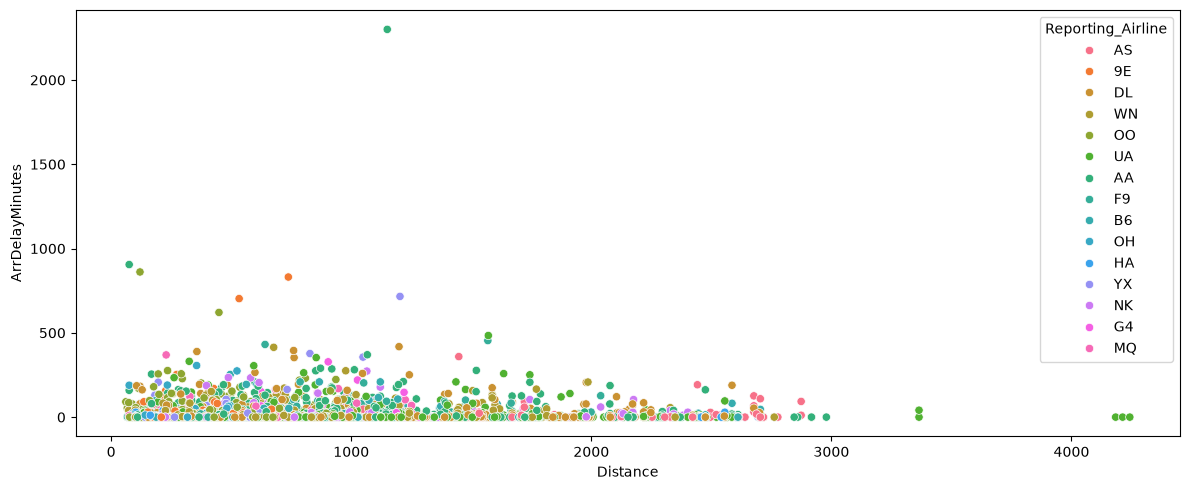

In [50]:
plt.figure(figsize=(12, 5))

sns.scatterplot(data= relation, x= relation["Distance"], y= relation["ArrDelayMinutes"], hue="Reporting_Airline")
plt.tight_layout()
plt.show()

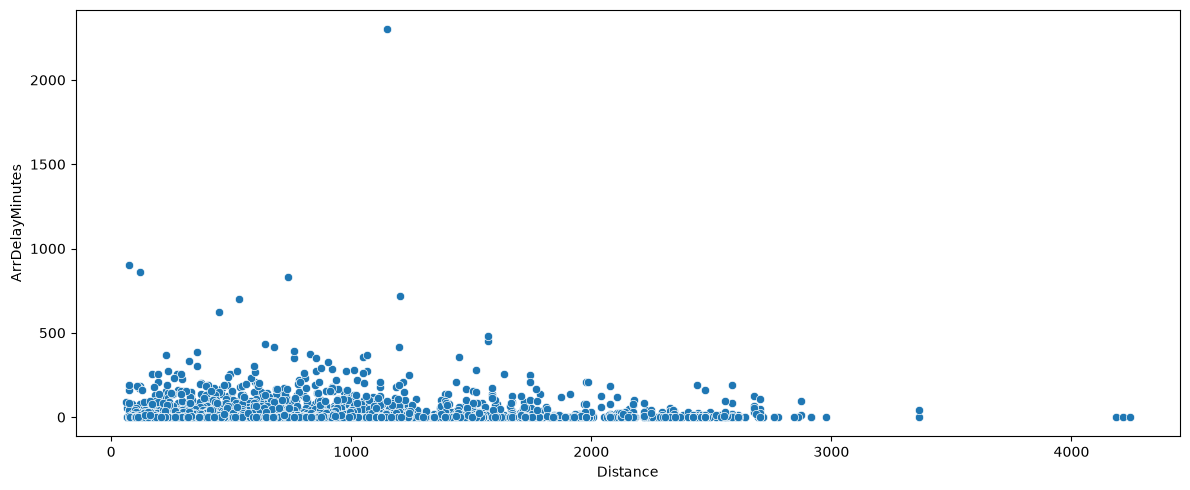

In [51]:
plt.figure(figsize=(12, 5))

sns.scatterplot(x= relation["Distance"], y= relation["ArrDelayMinutes"])
plt.tight_layout()
plt.show()

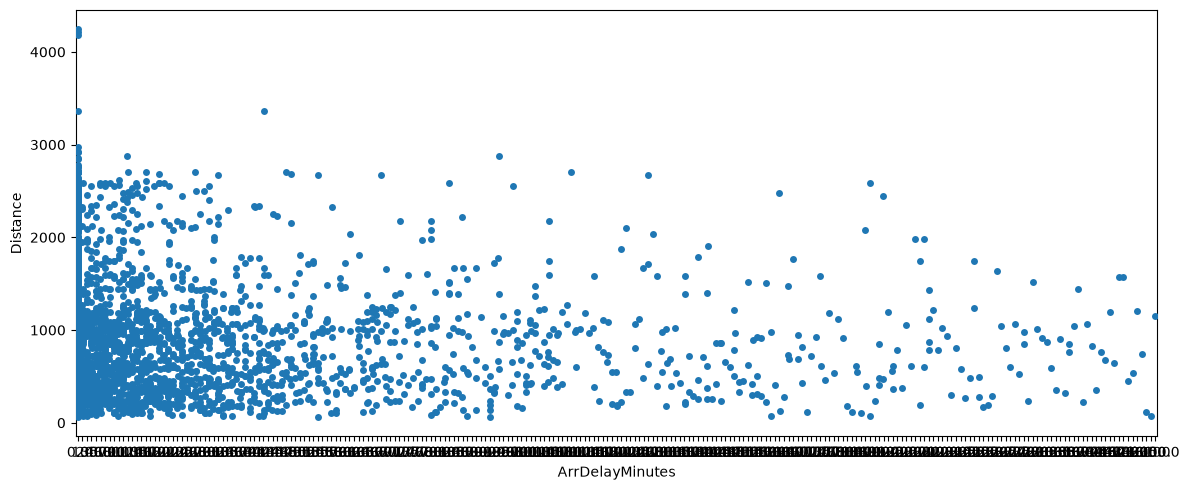

In [54]:
plt.figure(figsize=(12, 5))

sns.stripplot(data= relation, x="ArrDelayMinutes", y="Distance")
plt.tight_layout()
plt.show()

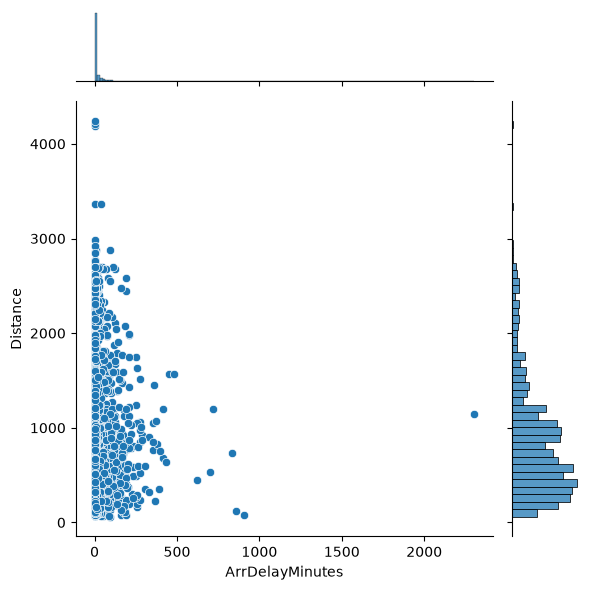

In [59]:
sns.jointplot(data= relation, x="ArrDelayMinutes", y="Distance", kind="scatter")
plt.tight_layout()
plt.show()

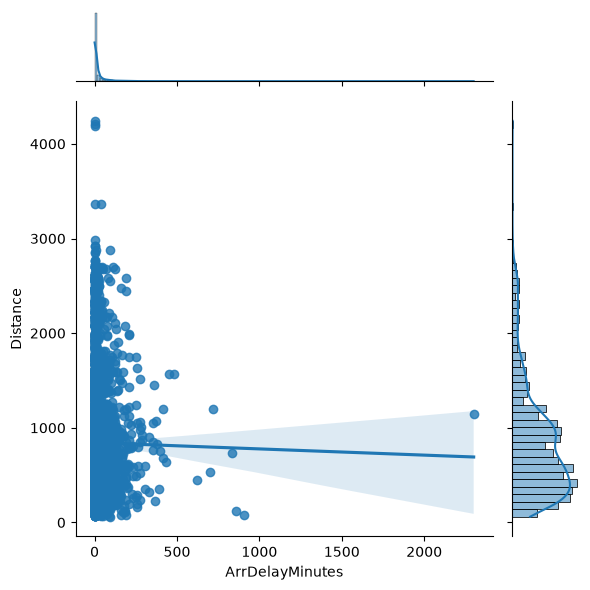

In [60]:
sns.jointplot(data= relation, x="ArrDelayMinutes", y="Distance", kind="reg")
plt.tight_layout()
plt.show()